# Exploración · Calidad del aire de Valencia

Validación local del pipeline antes de meterlo en Kubernetes Jobs.

**Arquitectura objetivo (4 Jobs)**:
1. **Ingest** — descarga CSV, filtra estación, recorta a la ventana (con buffer de 24 h para el lag).
2. **Impute** — rellena NaN en NO₂ con la media de los 4 registros previos.
3. **Train + Predict** — calcula features, entrena `LinearRegression`, predice 24 h.
4. **Plot** — gráfica histórica + predicción + banda MAE.

Cada sección del notebook se corresponde con uno de los Jobs.

In [12]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

CSV_URL = (
    "https://opendata.vlci.valencia.es/es/dataset/"
    "b5c2656c-6c1c-413d-a56e-549e52220502/resource/"
    "4be7248b-9597-4017-89af-82a9b6e2382f/download/"
    "rvvcca.-datos-horarios-valencia-2016-2021-curt-cas.csv"
)
STATION = "Pista Silla"
TARGET = "NO2"
WINDOW_START = "2021-07-01"
WINDOW_END = "2021-12-31"
BUFFER_HOURS = 24

DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)
RAW_CSV = DATA_DIR / "rvvcca_raw.csv"

## Job 1 · Ingest

1. Descarga el CSV completo (cacheado en `../data/rvvcca_raw.csv` — 47 MB).
2. Filtra por estación.
3. Construye la columna `timestamp` combinando `Fecha` y `Hora`.
4. Recorta a la ventana 2021-07-01 → 2021-12-31, **con un buffer de 24 h hacia atrás** para que el `lag-24` esté siempre definido en la primera hora de la ventana.

Output esperado: `raw.parquet` con columnas `[timestamp, NO2]`, sin imputar.

In [13]:
if not RAW_CSV.exists():
    print(f"Descargando CSV desde la API ({CSV_URL[:60]}...)...")
    response = requests.get(CSV_URL, timeout=60)
    response.raise_for_status()
    RAW_CSV.write_bytes(response.content)
    df_full = pd.read_csv(BytesIO(response.content), sep=";", encoding="utf-8-sig")
else:
    print(f"Usando CSV cacheado: {RAW_CSV}")
    df_full = pd.read_csv(RAW_CSV, sep=";", encoding="utf-8-sig")

print(f"Shape: {df_full.shape}")
df_full.head(3)

Usando CSV cacheado: ../data/rvvcca_raw.csv
Shape: (449026, 27)


,Fecha,Día de la semana,Día del mes,Hora,Estación,PM1,PM2.5,PM10,NO,NO2,...,C7H8,C6H6,Ruido,C8H10,Temperatura,Humedad relativa,Presión,Radiación,Precipitación,Velocidad máxima del viento
0,2020-01-01T00:00:00,Miércoles,1,0:00:00,Avda. Francia,NaN,77.0,83.0,16.0,45.0,...,NaN,NaN,NaN,NaN,6.6,89.0,1019.0,0.0,0.0,3.2
1,2020-01-01T00:00:00,Miércoles,1,1:00:00,Avda. Francia,NaN,65.0,70.0,20.0,37.0,...,NaN,NaN,NaN,NaN,6.2,89.0,1019.0,0.0,0.0,4.2
2,2020-01-01T00:00:00,Miércoles,1,2:00:00,Avda. Francia,NaN,47.0,51.0,16.0,35.0,...,NaN,NaN,NaN,NaN,5.9,90.0,1019.0,0.0,0.0,4.1


In [14]:
print("Estaciones únicas:")
for s in sorted(df_full["Estación"].unique()):
    print(f"  - {s}")

Estaciones únicas:
  - Avda. Francia
  - Bulevard Sud
  - Consellería Meteo
  - Molí del Sol
  - Nazaret Meteo
  - Pista Silla
  - Politécnico
  - Puerto Moll Trans. Ponent
  - Puerto Valencia
  - Puerto llit antic Túria
  - Valencia Centro
  - Viveros


In [15]:
raw = df_full[df_full["Estación"] == STATION].copy()
raw["timestamp"] = pd.to_datetime(
    raw["Fecha"].str.slice(0, 10) + " " + raw["Hora"],
    format="%Y-%m-%d %H:%M:%S",
)

buffer_start = pd.Timestamp(WINDOW_START) - pd.Timedelta(hours=BUFFER_HOURS)
window_end_inclusive = pd.Timestamp(WINDOW_END) + pd.Timedelta(hours=23)
raw = raw[(raw["timestamp"] >= buffer_start) & (raw["timestamp"] <= window_end_inclusive)]
raw = raw[["timestamp", TARGET]].sort_values("timestamp").reset_index(drop=True)

print(f"Filas tras ingest: {len(raw)}")
print(f"Rango (con buffer): {raw['timestamp'].min()} → {raw['timestamp'].max()}")
print(f"Nulls en {TARGET}: {raw[TARGET].isna().sum()} ({raw[TARGET].isna().mean():.1%})")
raw.head()

Filas tras ingest: 4440
Rango (con buffer): 2021-06-30 00:00:00 → 2021-12-31 23:00:00
Nulls en NO2: 142 (3.2%)


,timestamp,NO2
0,2021-06-30 00:00:00,1.0
1,2021-06-30 01:00:00,1.0
2,2021-06-30 02:00:00,2.0
3,2021-06-30 03:00:00,2.0
4,2021-06-30 04:00:00,5.0


Inspección visual de la serie cruda — los huecos verticales son los NaN que vamos a imputar en el Job 2.

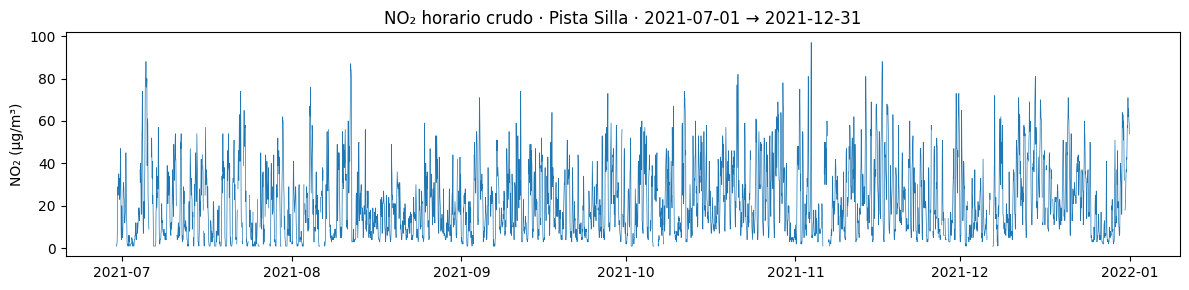

In [16]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(raw["timestamp"], raw[TARGET], linewidth=0.5)
ax.set_title(f"NO₂ horario crudo · {STATION} · {WINDOW_START} → {WINDOW_END}")
ax.set_ylabel("NO₂ (µg/m³)")
fig.tight_layout()

## Job 2 · Impute

Cada NaN en NO₂ se sustituye por la **media de los 4 registros inmediatamente anteriores** (ignorando otros NaN dentro de esa ventana). Si los 4 anteriores son todos NaN, el valor se queda en NaN — no debería ocurrir con el dataset actual (3.2 % nulls aislados).

Output esperado: `clean.parquet` con `[timestamp, NO2]` sin NaN.

In [17]:
clean = raw.copy()
n_before = clean[TARGET].isna().sum()

# Cada NaN ← media de los 4 valores previos. Iteramos para que las rachas
# largas de NaN se rellenen progresivamente usando los valores ya imputados
# en pasadas anteriores.
while clean[TARGET].isna().any():
    prev_nan = clean[TARGET].isna().sum()
    clean[TARGET] = clean[TARGET].fillna(
        clean[TARGET].shift(1).rolling(window=4, min_periods=1).mean()
    )
    if clean[TARGET].isna().sum() == prev_nan:
        break  # NaN al inicio de la serie (sin previos) — irrellenables

n_after = clean[TARGET].isna().sum()

print(f"NaN antes:   {n_before}")
print(f"NaN después: {n_after}")
print(f"Imputados:   {n_before - n_after}")
assert n_after == 0, "Quedan NaN tras la imputación — revisar la serie"
clean.head()

NaN antes:   142
NaN después: 0
Imputados:   142


,timestamp,NO2
0,2021-06-30 00:00:00,1.0
1,2021-06-30 01:00:00,1.0
2,2021-06-30 02:00:00,2.0
3,2021-06-30 03:00:00,2.0
4,2021-06-30 04:00:00,5.0


In [18]:
clean[clean[TARGET].isna()]

,timestamp,NO2


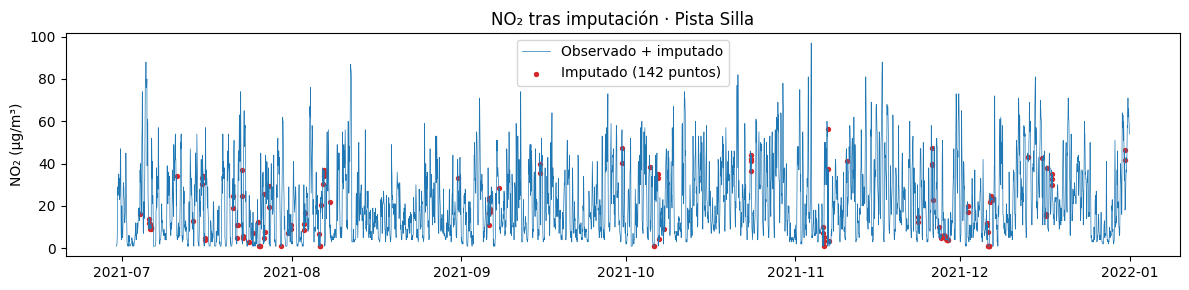

In [19]:
imputed_mask = raw[TARGET].isna()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(clean["timestamp"], clean[TARGET], linewidth=0.5, color="tab:blue", label="Observado + imputado")
ax.scatter(
    clean.loc[imputed_mask, "timestamp"],
    clean.loc[imputed_mask, TARGET],
    color="tab:red", s=8, label=f"Imputado ({imputed_mask.sum()} puntos)",
)
ax.set_title(f"NO₂ tras imputación · {STATION}")
ax.set_ylabel("NO₂ (µg/m³)")
ax.legend()
fig.tight_layout()

## Job 3 · Train + Predict

1. Calcula features `hour`, `dayofweek`, `no2_lag24` sobre la serie limpia.
2. Recorta el buffer inicial — a partir de aquí el dataset cubre exactamente la ventana solicitada.
3. Split temporal 80/20.
4. Entrena `LinearRegression` y mide MAE.
5. Predice las próximas 24 h.

Output esperado: `dataset.parquet`, `predictions.csv`, `metrics.json`.

In [20]:
df = clean.copy()
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["no2_lag24"] = df[TARGET].shift(24)

df = df[df["timestamp"] >= WINDOW_START].reset_index(drop=True)

print(f"Filas en la ventana: {len(df)}")
print(f"NaN por columna:\n{df.isna().sum()}")
df.head()

Filas en la ventana: 4416
NaN por columna:
timestamp    0
NO2          0
hour         0
dayofweek    0
no2_lag24    0
dtype: int64


,timestamp,NO2,hour,dayofweek,no2_lag24
0,2021-07-01 00:00:00,20.0,0,3,1.0
1,2021-07-01 01:00:00,11.0,1,3,1.0
2,2021-07-01 02:00:00,7.0,2,3,2.0
3,2021-07-01 03:00:00,7.0,3,3,2.0
4,2021-07-01 04:00:00,5.0,4,3,5.0


In [21]:
FEATURES = ["hour", "dayofweek", "no2_lag24"]

split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

model = LinearRegression()
model.fit(train[FEATURES], train[TARGET])

preds_test = model.predict(test[FEATURES])
mae = mean_absolute_error(test[TARGET], preds_test)

print(f"Train: {len(train)} filas ({train['timestamp'].min()} → {train['timestamp'].max()})")
print(f"Test:  {len(test)} filas ({test['timestamp'].min()} → {test['timestamp'].max()})")
print(f"MAE en test: {mae:.2f} µg/m³")
print(f"Coeficientes: {dict(zip(FEATURES, model.coef_.round(3)))}")
print(f"Intercepto: {model.intercept_:.3f}")

Train: 3532 filas (2021-07-01 00:00:00 → 2021-11-25 03:00:00)
Test:  884 filas (2021-11-25 04:00:00 → 2021-12-31 23:00:00)
MAE en test: 12.04 µg/m³
Coeficientes: {'hour': np.float64(0.425), 'dayofweek': np.float64(-1.342), 'no2_lag24': np.float64(0.302)}
Intercepto: 14.043


In [22]:
last_ts = df["timestamp"].iloc[-1]
future_ts = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=24, freq="h")

history = df.set_index("timestamp")[TARGET]

future = pd.DataFrame({"timestamp": future_ts})
future["hour"] = future["timestamp"].dt.hour
future["dayofweek"] = future["timestamp"].dt.dayofweek
future["no2_lag24"] = [history.get(ts - pd.Timedelta(hours=24)) for ts in future["timestamp"]]

assert future[FEATURES].notna().all().all(), "Hay NaN en features de predicción — la serie limpia debería evitar esto"
future["prediction"] = model.predict(future[FEATURES])

future

,timestamp,hour,dayofweek,no2_lag24,prediction
0,2022-01-01 00:00:00,0,5,39.000000,19.110940
1,2022-01-01 01:00:00,1,5,32.000000,17.421893
2,2022-01-01 02:00:00,2,5,46.250000,22.151835
3,2022-01-01 03:00:00,3,5,41.666667,21.192790
4,2022-01-01 04:00:00,4,5,18.000000,14.469241
5,2022-01-01 05:00:00,5,5,19.000000,15.196755
6,2022-01-01 06:00:00,6,5,22.000000,16.528408
7,2022-01-01 07:00:00,7,5,28.000000,18.766272
8,2022-01-01 08:00:00,8,5,33.000000,20.702066
9,2022-01-01 09:00:00,9,5,37.000000,22.335789


## Job 4 · Plot

Output esperado: `forecast.png`.

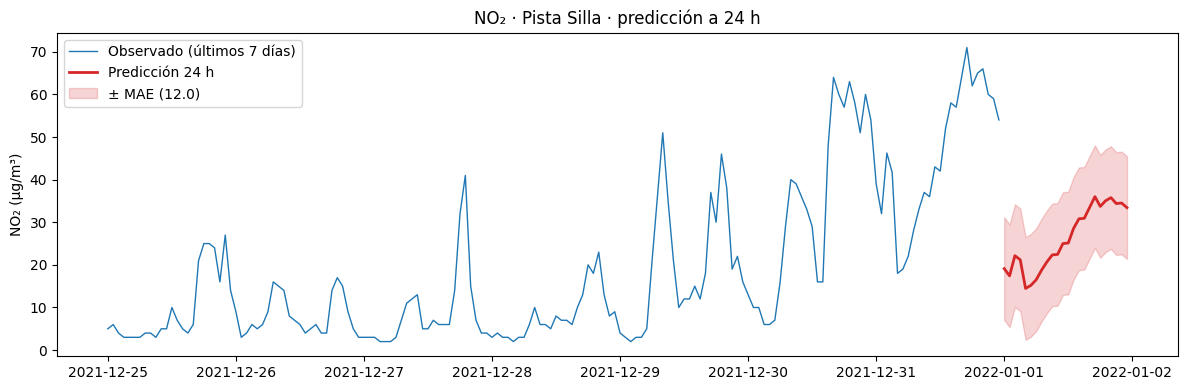

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/francescdomenechvillalba/Desktop/MASTER_CLOUD/TRIMESTRE_3/CBD/air-quality/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/francescdomenechvillalba/Desktop/MASTER_CLOUD/TRIMESTRE_3/CBD/air-quality/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/Users/francescdomenechvillalba/Desktop/MASTER_CLOUD/TRIMESTRE_3/CBD/air-quality/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/francescdomenechvillalba/Desktop/MASTER_CLOUD/TRIMESTRE_3/CBD/air-quality/.venv/lib/python3.12/site-packages/jupyter_client/session.py", line 998, in feed_identities
    ra

In [23]:
tail = df.tail(24 * 7)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tail["timestamp"], tail[TARGET], label="Observado (últimos 7 días)", linewidth=1)
ax.plot(future["timestamp"], future["prediction"], label="Predicción 24 h", linewidth=2, color="tab:red")
ax.fill_between(
    future["timestamp"],
    future["prediction"] - mae,
    future["prediction"] + mae,
    alpha=0.2, color="tab:red", label=f"± MAE ({mae:.1f})",
)
ax.set_title(f"NO₂ · {STATION} · predicción a 24 h")
ax.set_ylabel("NO₂ (µg/m³)")
ax.legend()
fig.tight_layout()

## Artefactos generados

Los 4 Jobs producirán equivalentes a estos ficheros.

In [13]:
import json

raw.to_parquet(DATA_DIR / "raw.parquet", index=False)
clean.to_parquet(DATA_DIR / "clean.parquet", index=False)
df.to_parquet(DATA_DIR / "dataset.parquet", index=False)
future[["timestamp", "prediction"]].to_csv(DATA_DIR / "predictions.csv", index=False)
(DATA_DIR / "metrics.json").write_text(json.dumps({"mae": float(mae), "n_train": len(train), "n_test": len(test)}, indent=2))

print("Artefactos generados:")
for p in sorted(DATA_DIR.iterdir()):
    print(f"  {p.name} ({p.stat().st_size / 1024:.1f} KB)")

Artefactos generados:
  clean.parquet (43.6 KB)
  dataset.parquet (50.4 KB)
  metrics.json (0.1 KB)
  predictions.csv (0.9 KB)
  raw.parquet (42.7 KB)
  rvvcca_raw.csv (46755.0 KB)
